# Stage-A Activity Public Module

This notebook provides a lightweight, reviewer-facing public module for the **Stage-A activity regression model**.

It is intentionally limited to five parts:

1. Load the public 578-sample activity table and the fixed Dev/Lockbox split  
2. Run coarse benchmarking on **Dev only**  
3. Load the frozen tuned random-forest model and report **OOF** performance on **Dev only**  
4. Compute **SHAP** feature importance and dependence plots on **Dev only**  
5. Report final held-out performance on **Lockbox only**


In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RepeatedKFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({"savefig.dpi": 600, "savefig.bbox": "tight"})

ROOT = Path(".").resolve()
DATA_CSV = ROOT / "data" / "activity_stageA_578_best24.csv"
SPLIT_CSV = ROOT / "data" / "activity_stageA_split.csv"
FEATURE_JSON = ROOT / "models" / "activity_features.json"
MODEL_FILE = ROOT / "models" / "RandomForest_StageA_tuned_bestk24.joblib"
META_JSON = ROOT / "models" / "activity_tuned_meta.json"

OUT = ROOT / "public_outputs"
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
for p in [OUT, FIG_DIR, TAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_COL = "targets"
SUBSET_COL = "subset"
GROUP_COL = "group_key"
PREFERRED_ID_COLS = ["MOFID", "sample_id"]
SEED = 42

def save_df(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved: {path.resolve()}")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def scatter_identity(y_true, y_pred, title, out_png, unit="eV"):
    fig, ax = plt.subplots(figsize=(6.2, 5.8))
    ax.scatter(y_true, y_pred, s=42, facecolors="none", edgecolors="#149E8A", linewidths=1.2)
    lims = [min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))]
    pad = 0.05 * (lims[1] - lims[0] if lims[1] > lims[0] else 1.0)
    lims = [lims[0] - pad, lims[1] + pad]
    ax.plot(lims, lims, ls=(0, (4, 2)), color="#6B7280", lw=1.0)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"True ({unit})")
    ax.set_ylabel(f"Predicted ({unit})")
    ax.set_title(title)
    txt = f"RMSE={rmse(y_true, y_pred):.3f} {unit}\nMAE={mean_absolute_error(y_true, y_pred):.3f} {unit}\nR²={r2_score(y_true, y_pred):.3f}"
    ax.text(0.98, 0.02, txt, transform=ax.transAxes, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.9, edgecolor="#D1D5DB"))
    fig.tight_layout()
    fig.savefig(out_png)
    plt.show()
    plt.close(fig)


In [3]:
assert DATA_CSV.exists(), f"Missing: {DATA_CSV}"
assert SPLIT_CSV.exists(), f"Missing: {SPLIT_CSV}"
assert FEATURE_JSON.exists(), f"Missing: {FEATURE_JSON}"
assert MODEL_FILE.exists(), f"Missing: {MODEL_FILE}"
assert META_JSON.exists(), f"Missing: {META_JSON}"

df = pd.read_csv(DATA_CSV)
split_df = pd.read_csv(SPLIT_CSV)

with open(FEATURE_JSON, "r", encoding="utf-8") as f:
    final_feats = json.load(f)
with open(META_JSON, "r", encoding="utf-8") as f:
    tuned_meta = json.load(f)

ID_COL = next((c for c in PREFERRED_ID_COLS if c in df.columns and c in split_df.columns), None)
assert ID_COL is not None, f"Could not find a shared ID column. Candidates: {PREFERRED_ID_COLS}"
assert TARGET_COL in df.columns, f"Missing {TARGET_COL} in data table"
assert SUBSET_COL in split_df.columns, f"Missing {SUBSET_COL} in split table"

missing_feats = [c for c in final_feats if c not in df.columns]
assert not missing_feats, f"Missing features in data table: {missing_feats[:10]}"

dat = df.merge(split_df, on=ID_COL, how="left", validate="one_to_one")
assert dat[SUBSET_COL].notna().all(), "Some samples are missing split assignment"

if GROUP_COL not in dat.columns:
    dat[GROUP_COL] = dat[ID_COL].astype(str)

dat[TARGET_COL] = dat[TARGET_COL].astype(float)

dev_df = dat[dat[SUBSET_COL].str.lower() == "dev"].copy()
lock_df = dat[dat[SUBSET_COL].str.lower().isin(["lockbox", "lock"])].copy()

assert len(dev_df) > 0, "Dev subset is empty"
assert len(lock_df) > 0, "Lockbox subset is empty"

X_dev = dev_df[final_feats].apply(pd.to_numeric, errors="coerce")
X_lock = lock_df[final_feats].apply(pd.to_numeric, errors="coerce")
med_dev = X_dev.median(numeric_only=True)
X_dev = X_dev.fillna(med_dev)
X_lock = X_lock.fillna(med_dev)

y_dev = dev_df[TARGET_COL].to_numpy(dtype=float)
y_lock = lock_df[TARGET_COL].to_numpy(dtype=float)

summary = pd.DataFrame({
    "subset": ["Full", "Dev", "Lockbox"],
    "n_samples": [len(dat), len(dev_df), len(lock_df)],
    "target_mean": [dat[TARGET_COL].mean(), dev_df[TARGET_COL].mean(), lock_df[TARGET_COL].mean()],
    "target_std": [dat[TARGET_COL].std(ddof=1), dev_df[TARGET_COL].std(ddof=1), lock_df[TARGET_COL].std(ddof=1)],
    "n_groups": [dat[GROUP_COL].nunique(), dev_df[GROUP_COL].nunique(), lock_df[GROUP_COL].nunique()],
})
display(summary)
save_df(summary, TAB_DIR / "subset_summary.csv")


,subset,n_samples,target_mean,target_std,n_groups
0,Full,578,0.758492,0.632119,578
1,Dev,491,0.745396,0.628282,491
2,Lockbox,87,0.832403,0.652130,87


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\subset_summary.csv


## Part 1 — Coarse benchmarking on Dev only

In [4]:
NEED_SCALER = {"Linear", "Ridge", "Lasso", "ElasticNet", "BayesianRidge", "SVR_RBF", "KNN"}

MODELS = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=SEED),
    "Lasso": Lasso(alpha=1e-3, random_state=SEED),
    "ElasticNet": ElasticNet(alpha=1e-3, l1_ratio=0.5, random_state=SEED),
    "BayesianRidge": BayesianRidge(),
    "SVR_RBF": SVR(kernel="rbf", C=10, gamma="scale"),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED),
    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=600, random_state=SEED, n_jobs=-1),
    "GBDT": GradientBoostingRegressor(random_state=SEED),
    "AdaBoost": AdaBoostRegressor(random_state=SEED),
    "Bagging": BaggingRegressor(random_state=SEED, n_estimators=250, n_jobs=-1),
    "XGB": XGBRegressor(
        objective="reg:squarederror",
        random_state=SEED,
        n_estimators=800,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        verbosity=0,
        n_jobs=-1,
    ),
    "LightGBM": LGBMRegressor(
        random_state=SEED,
        n_estimators=800,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        num_leaves=31,
        reg_alpha=0.0,
        reg_lambda=0.0,
        n_jobs=-1,
        verbosity=-1,
    ),
}

try:
    from catboost import CatBoostRegressor
    MODELS["CatBoost"] = CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
        thread_count=4,
    )
except Exception:
    pass

CV_SCHEMES = {
    "CV5": KFold(n_splits=5, shuffle=True, random_state=SEED),
    "CV10": KFold(n_splits=10, shuffle=True, random_state=SEED),
    "Rep5x3": RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED),
}

RMSE_SCORER = make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False)
rows = []

for mdl_name, mdl in MODELS.items():
    steps = [("mdl", mdl)]
    if mdl_name in NEED_SCALER:
        steps.insert(0, ("scaler", StandardScaler()))
    pipe = Pipeline(steps)

    for cv_name, cv_obj in CV_SCHEMES.items():
        try:
            cv_res = cross_validate(
                pipe,
                X_dev,
                y_dev,
                cv=cv_obj,
                scoring={"neg_RMSE": RMSE_SCORER, "R2": "r2"},
                n_jobs=-1,
                return_train_score=False,
                error_score="raise",
            )
            rows.append({
                "Model": mdl_name,
                "CV": cv_name,
                "RMSE_mean": float(-cv_res["test_neg_RMSE"].mean()),
                "RMSE_std": float(cv_res["test_neg_RMSE"].std(ddof=1)),
                "R2_mean": float(cv_res["test_R2"].mean()),
                "R2_std": float(cv_res["test_R2"].std(ddof=1)),
                "k_features": len(final_feats),
            })
        except Exception as e:
            rows.append({
                "Model": mdl_name,
                "CV": cv_name,
                "RMSE_mean": np.nan,
                "RMSE_std": np.nan,
                "R2_mean": np.nan,
                "R2_std": np.nan,
                "k_features": len(final_feats),
                "error": repr(e),
            })

cv_df = pd.DataFrame(rows).sort_values(["RMSE_mean", "Model", "CV"], na_position="last").reset_index(drop=True)
display(cv_df.head(12))
save_df(cv_df, TAB_DIR / "activity_stageA_coarse_cv_results.csv")

leader = (cv_df.dropna(subset=["RMSE_mean"])
            .groupby("Model", as_index=False)
            .agg(RMSE_cv_avg=("RMSE_mean", "mean"),
                 RMSE_cv_std=("RMSE_mean", "std"),
                 R2_cv_avg=("R2_mean", "mean")))
leader = leader.sort_values("RMSE_cv_avg", ascending=True).reset_index(drop=True)
display(leader.head(10))
save_df(leader, TAB_DIR / "activity_stageA_leaderboard.csv")

top3 = leader.nsmallest(3, "RMSE_cv_avg").copy()
display(top3)
save_df(top3, TAB_DIR / "activity_stageA_top3_models.csv")


,Model,CV,RMSE_mean,RMSE_std,R2_mean,R2_std,k_features
0,RandomForest,CV10,0.132122,0.024286,0.952383,0.016303,24
1,Bagging,CV10,0.132201,0.024399,0.952306,0.016494,24
2,GBDT,CV10,0.133689,0.022509,0.950530,0.018397,24
3,RandomForest,CV5,0.137606,0.017292,0.949847,0.010837,24
4,GBDT,Rep5x3,0.137663,0.013309,0.949281,0.012369,24
5,GBDT,CV5,0.137760,0.010325,0.949389,0.011144,24
6,Bagging,CV5,0.138009,0.017527,0.949590,0.010717,24
7,RandomForest,Rep5x3,0.139369,0.015258,0.948304,0.012194,24
8,Bagging,Rep5x3,0.139496,0.015249,0.948217,0.012106,24
9,ExtraTrees,CV10,0.141712,0.024759,0.944903,0.019566,24


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_stageA_coarse_cv_results.csv


,Model,RMSE_cv_avg,RMSE_cv_std,R2_cv_avg
0,RandomForest,0.136366,0.003779,0.950178
1,GBDT,0.136371,0.002323,0.949733
2,Bagging,0.136569,0.003855,0.950038
3,ExtraTrees,0.144320,0.002310,0.944179
4,XGB,0.149547,0.001884,0.939749
5,LightGBM,0.151535,0.004475,0.938080
6,DecisionTree,0.161812,0.004524,0.930095
7,SVR_RBF,0.164585,0.005809,0.926844
8,AdaBoost,0.188565,0.004053,0.903792
9,KNN,0.230943,0.005751,0.856198


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_stageA_leaderboard.csv


,Model,RMSE_cv_avg,RMSE_cv_std,R2_cv_avg
0,RandomForest,0.136366,0.003779,0.950178
1,GBDT,0.136371,0.002323,0.949733
2,Bagging,0.136569,0.003855,0.950038


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_stageA_top3_models.csv


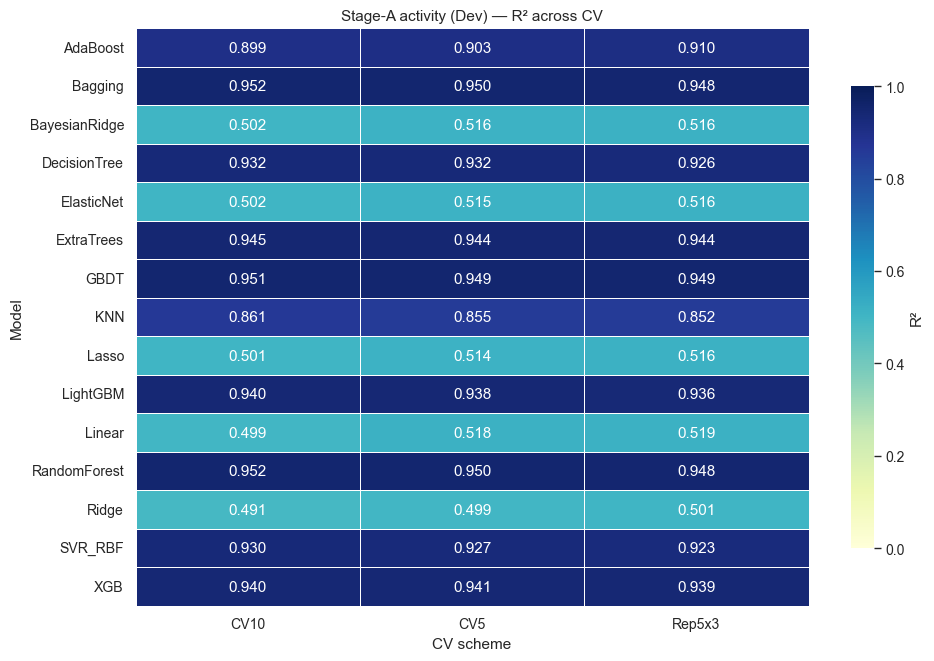

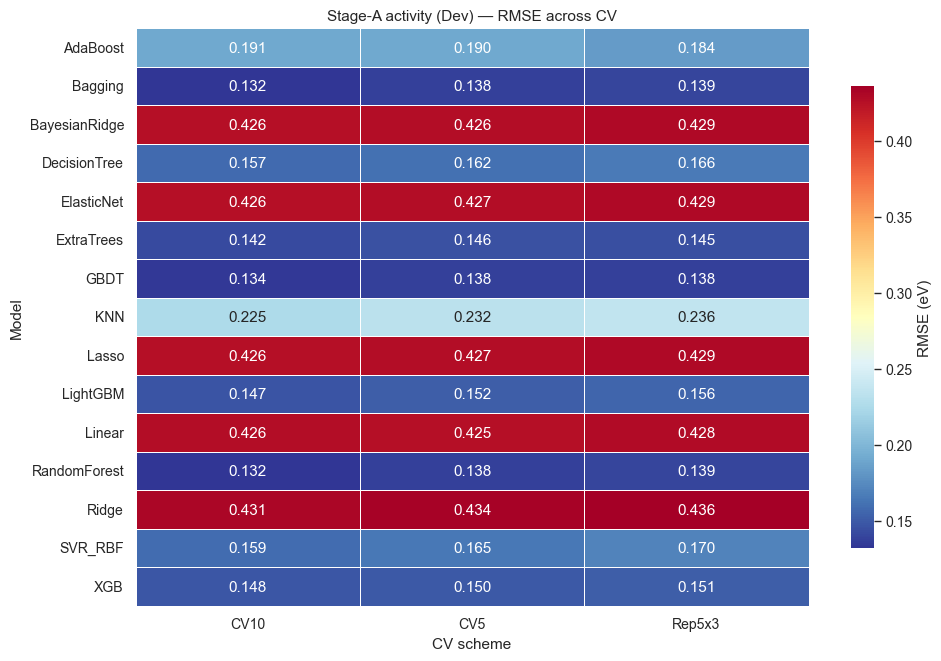

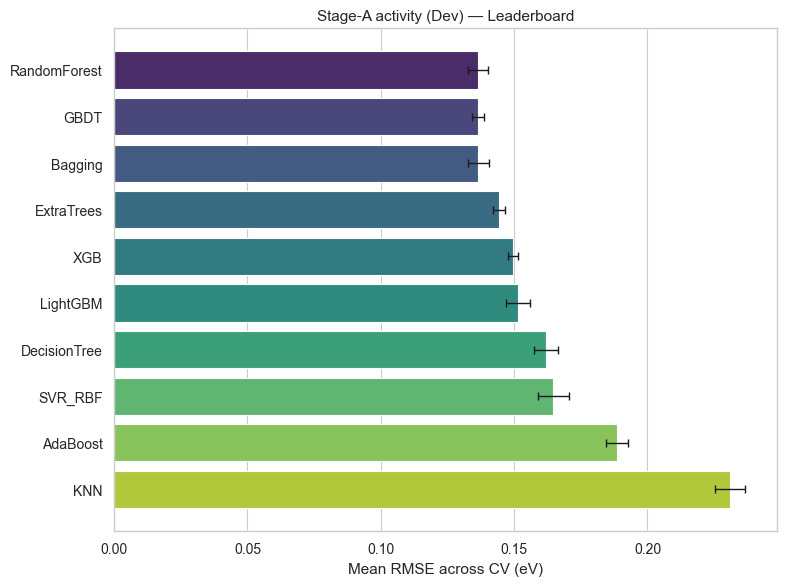

In [5]:
pivot_r2 = cv_df.pivot(index="Model", columns="CV", values="R2_mean")
fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(pivot_r2))))
sns.heatmap(pivot_r2, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.0, vmax=1.0,
            linewidths=.5, linecolor="white", cbar_kws={"shrink": .8, "label": "R²"}, ax=ax)
ax.set_title("Stage-A activity (Dev) — R² across CV")
ax.set_xlabel("CV scheme")
ax.set_ylabel("Model")
fig.tight_layout()
fig.savefig(FIG_DIR / "activity_stageA_heatmap_R2.png")
plt.show()
plt.close(fig)

pivot_rmse = cv_df.pivot(index="Model", columns="CV", values="RMSE_mean")
fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(pivot_rmse))))
sns.heatmap(pivot_rmse, annot=True, fmt=".3f", cmap=sns.color_palette("RdYlBu_r", as_cmap=True),
            linewidths=.5, linecolor="white", cbar_kws={"shrink": .8, "label": "RMSE (eV)"}, ax=ax)
ax.set_title("Stage-A activity (Dev) — RMSE across CV")
ax.set_xlabel("CV scheme")
ax.set_ylabel("Model")
fig.tight_layout()
fig.savefig(FIG_DIR / "activity_stageA_heatmap_RMSE.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.0, 6.0))
sns.barplot(data=leader.head(10), x="RMSE_cv_avg", y="Model", palette="viridis", ax=ax)
for i, (m, s) in enumerate(zip(leader.head(10)["RMSE_cv_avg"], leader.head(10)["RMSE_cv_std"].fillna(0.0))):
    ax.errorbar(x=m, y=i, xerr=s, fmt="none", ecolor="k", elinewidth=1, capsize=3)
ax.set_xlabel("Mean RMSE across CV (eV)")
ax.set_ylabel("")
ax.set_title("Stage-A activity (Dev) — Leaderboard")
fig.tight_layout()
fig.savefig(FIG_DIR / "activity_stageA_leaderboard_top10.png")
plt.show()
plt.close(fig)


## Part 2 — Frozen tuned random-forest model: OOF on Dev

In [6]:
tuned_model = joblib.load(MODEL_FILE)
print("Loaded:", MODEL_FILE.name)

def get_oof_cv(meta: dict, seed: int = 42):
    cv = meta.get("oof_cv_for_public", {})
    if cv.get("type") == "RepeatedKFold":
        return RepeatedKFold(
            n_splits=int(cv.get("n_splits", 5)),
            n_repeats=int(cv.get("n_repeats", 3)),
            random_state=int(cv.get("random_state", seed)),
        )
    return RepeatedKFold(n_splits=5, n_repeats=3, random_state=seed)

oof_cv = get_oof_cv(tuned_meta, seed=SEED)

pred_sum = np.zeros(len(X_dev), dtype=float)
pred_cnt = np.zeros(len(X_dev), dtype=float)
fold_rows = []

for fold_id, (tr_idx, va_idx) in enumerate(oof_cv.split(X_dev, y_dev), start=1):
    est = clone(tuned_model)
    est.fit(X_dev.iloc[tr_idx], y_dev[tr_idx])
    pred = est.predict(X_dev.iloc[va_idx])

    pred_sum[va_idx] += pred
    pred_cnt[va_idx] += 1.0

    fold_rows.append({
        "fold": fold_id,
        "n_train": int(len(tr_idx)),
        "n_valid": int(len(va_idx)),
        "RMSE": rmse(y_dev[va_idx], pred),
        "MAE": float(mean_absolute_error(y_dev[va_idx], pred)),
        "R2": float(r2_score(y_dev[va_idx], pred)),
    })

y_oof = pred_sum / np.maximum(pred_cnt, 1.0)
oof_metrics = pd.DataFrame([{
    "RMSE": rmse(y_dev, y_oof),
    "MAE": float(mean_absolute_error(y_dev, y_oof)),
    "R2": float(r2_score(y_dev, y_oof)),
    "n_samples": int(len(y_dev)),
    "n_features": int(len(final_feats)),
}])
fold_df = pd.DataFrame(fold_rows)

display(oof_metrics)
display(fold_df.head())

save_df(oof_metrics, TAB_DIR / "activity_oof_metrics_dev.csv")
save_df(fold_df, TAB_DIR / "activity_oof_folds_dev.csv")
save_df(pd.DataFrame({ID_COL: dev_df[ID_COL].values, "y_true": y_dev, "y_pred": y_oof}), TAB_DIR / "activity_oof_predictions_dev.csv")


Loaded: RandomForest_StageA_tuned_bestk24.joblib


,RMSE,MAE,R2,n_samples,n_features
0,0.134416,0.092364,0.954135,491,24


,fold,n_train,n_valid,RMSE,MAE,R2
0,1,392,99,0.147810,0.099401,0.950954
1,2,393,98,0.130979,0.092782,0.963861
2,3,393,98,0.145085,0.106199,0.932406
3,4,393,98,0.108141,0.080681,0.963431
4,5,393,98,0.150817,0.095634,0.939465


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_oof_metrics_dev.csv
Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_oof_folds_dev.csv
Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_oof_predictions_dev.csv


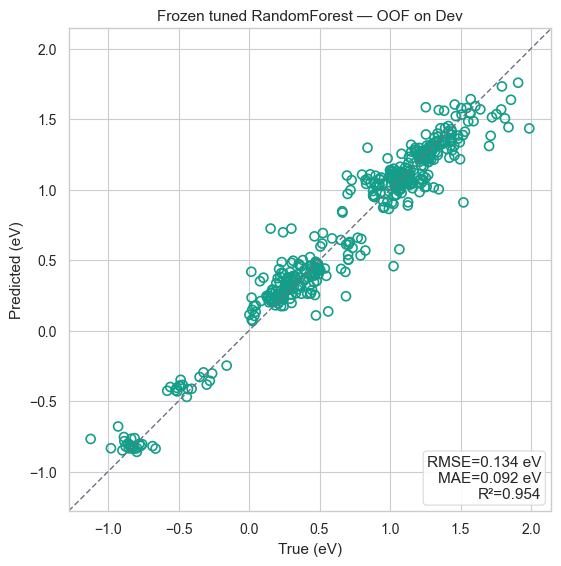

In [7]:
scatter_identity(
    y_dev,
    y_oof,
    title="Frozen tuned RandomForest — OOF on Dev",
    out_png=FIG_DIR / "activity_oof_scatter_dev.png",
    unit="eV",
)


## Part 3 — SHAP on Dev only

In [8]:
import shap

def unwrap_for_shap(obj):
    if hasattr(obj, "base_fitted_") and getattr(obj, "base_fitted_", None) is not None:
        return obj.base_fitted_
    if hasattr(obj, "base_estimator") and getattr(obj, "base_estimator", None) is not None:
        return obj.base_estimator
    if hasattr(obj, "steps"):
        return obj.steps[-1][1]
    if hasattr(obj, "named_steps") and len(obj.named_steps):
        return list(obj.named_steps.values())[-1]
    return obj

base_model_for_shap = unwrap_for_shap(tuned_model)
print("SHAP base model:", base_model_for_shap.__class__.__name__)

X_shap = X_dev.copy()

explainer = shap.TreeExplainer(
    model=base_model_for_shap,
    data=X_shap,
    feature_names=final_feats,
    model_output="raw",
    feature_perturbation="interventional",
)

shap_values_raw = explainer.shap_values(X_shap, check_additivity=False)

if isinstance(shap_values_raw, list):
    shap_values = np.asarray(shap_values_raw[0], dtype=float)
else:
    shap_values_raw = np.asarray(shap_values_raw)
    shap_values = np.asarray(shap_values_raw, dtype=float)

mean_abs = np.abs(shap_values).mean(axis=0)
shap_imp = pd.DataFrame({
    "feature": final_feats,
    "mean_abs_shap": mean_abs
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

display(shap_imp.head(15))
save_df(shap_imp, TAB_DIR / "activity_shap_importance_dev.csv")
np.save(TAB_DIR / "activity_shap_values_dev.npy", shap_values)


SHAP base model: RandomForestRegressor


 99%|===================| 487/491 [00:59<00:00]        

,feature,mean_abs_shap
0,EM,0.093177
1,m,0.078961
2,Vatomic,0.070818
3,SpMax2_Bh_m,0.063842
4,EE_B_p,0.056536
5,P,0.053274
6,ratomic,0.050748
7,SpMin1_Bh_s,0.035553
8,ATSC1p,0.016669
9,ATSC1e,0.013707


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_shap_importance_dev.csv


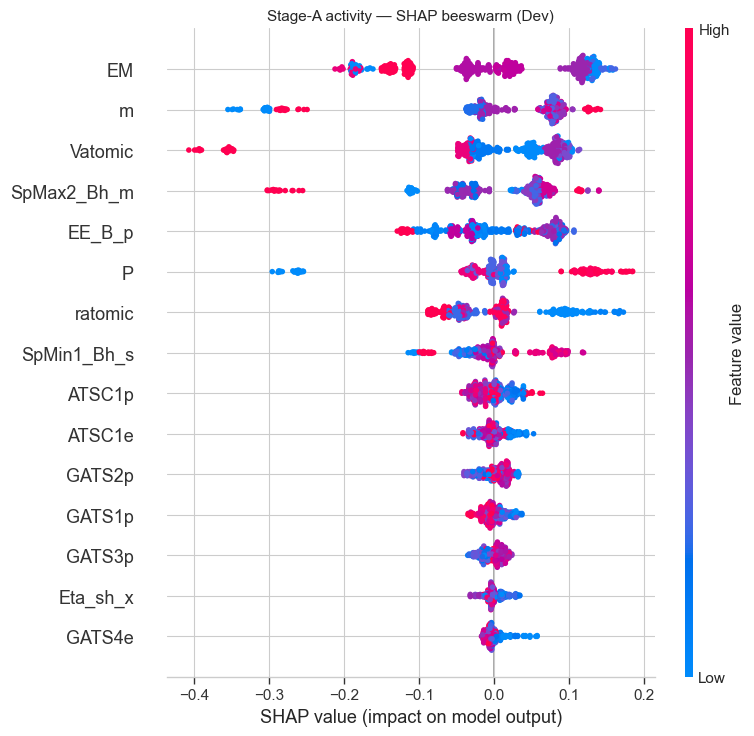

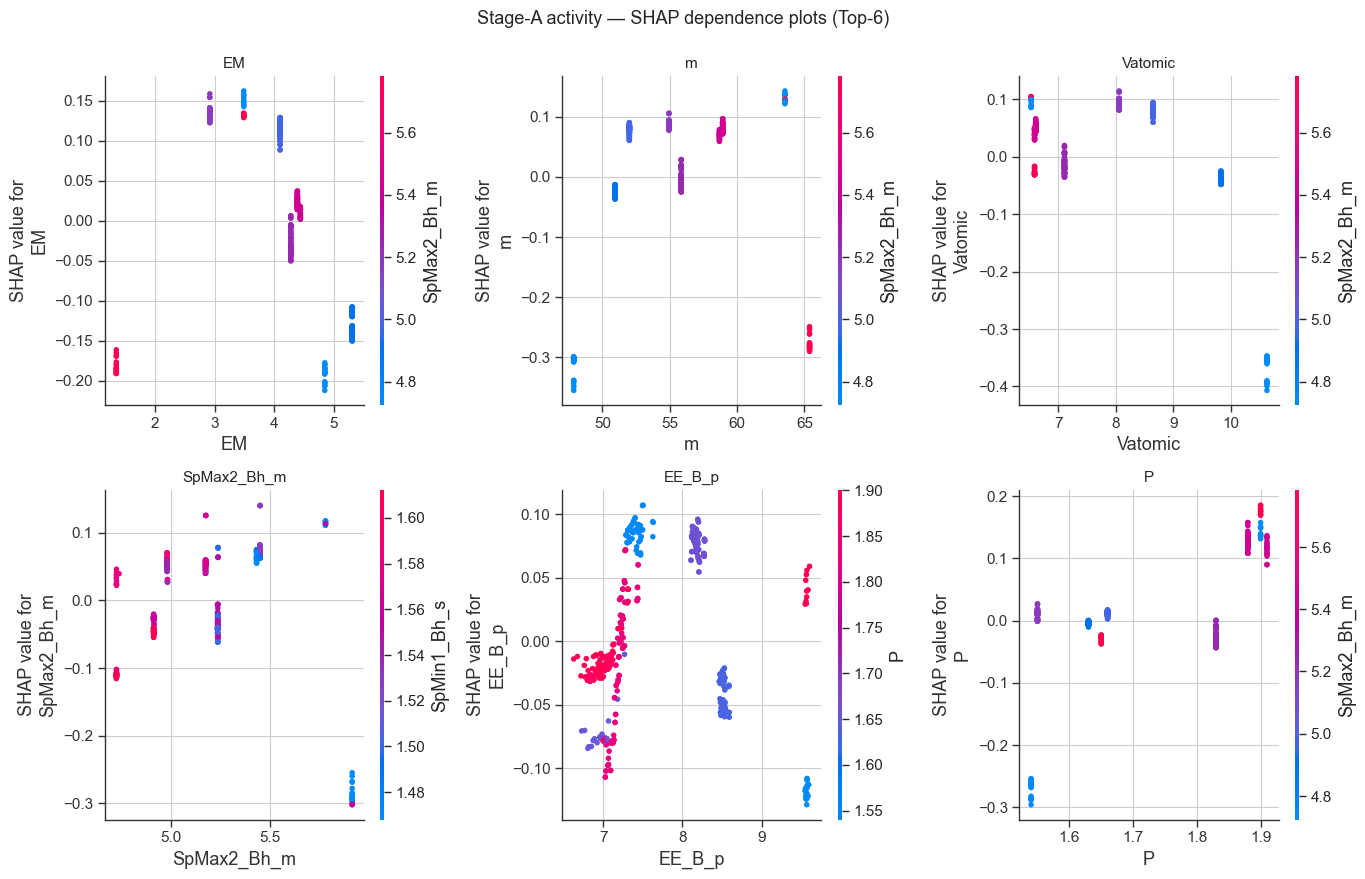

In [9]:
plt.figure(figsize=(7.6, 6.2))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=final_feats,
    max_display=15,
    show=False
)
plt.title("Stage-A activity — SHAP beeswarm (Dev)")
plt.tight_layout()
plt.savefig(FIG_DIR / "activity_shap_beeswarm_dev.png")
plt.show()
plt.close()

top6 = shap_imp["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(13.8, 8.8))
axes = axes.ravel()
for ax, feat in zip(axes, top6):
    plt.sca(ax)
    try:
        shap.dependence_plot(feat, shap_values, X_shap, feature_names=final_feats, show=False, ax=ax)
    except TypeError:
        shap.dependence_plot(feat, shap_values, X_shap, feature_names=final_feats, show=False)
    ax.set_title(feat, fontsize=11)
for ax in axes[len(top6):]:
    ax.axis("off")
fig.suptitle("Stage-A activity — SHAP dependence plots (Top-6)", y=0.995, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "activity_shap_dependence_top6_dev.png")
plt.show()
plt.close(fig)


## Part 4 — Held-out Lockbox evaluation

,RMSE,MAE,R2,n_samples,n_features
0,0.144488,0.093835,0.950339,87,24


Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_lockbox_metrics.csv
Saved: C:\Users\Administrator\ML\ML\ML\ML-Activity-Regression\public_outputs\tables\activity_lockbox_predictions.csv


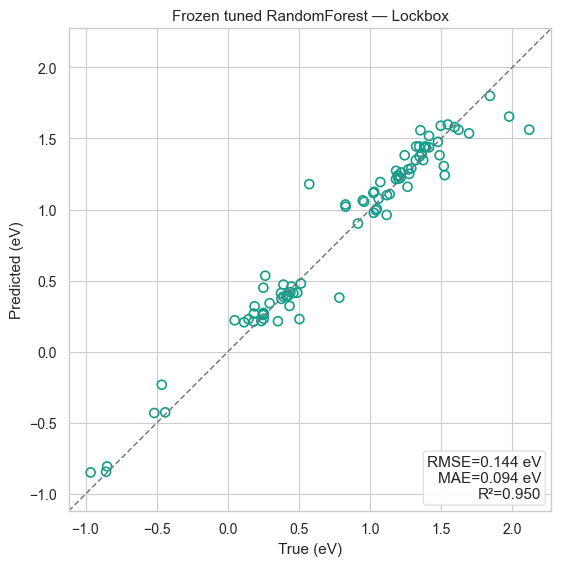

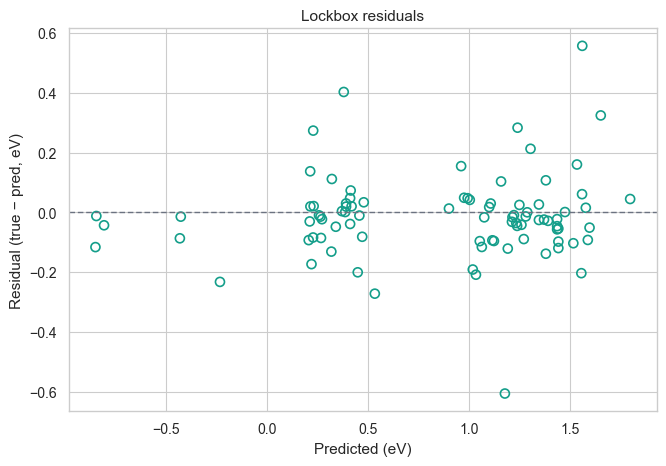

In [10]:
y_lock_pred = tuned_model.predict(X_lock)

lock_metrics = pd.DataFrame([{
    "RMSE": rmse(y_lock, y_lock_pred),
    "MAE": float(mean_absolute_error(y_lock, y_lock_pred)),
    "R2": float(r2_score(y_lock, y_lock_pred)),
    "n_samples": int(len(y_lock)),
    "n_features": int(len(final_feats)),
}])

display(lock_metrics)
save_df(lock_metrics, TAB_DIR / "activity_lockbox_metrics.csv")
save_df(pd.DataFrame({ID_COL: lock_df[ID_COL].values, "y_true": y_lock, "y_pred": y_lock_pred}), TAB_DIR / "activity_lockbox_predictions.csv")

scatter_identity(
    y_lock,
    y_lock_pred,
    title="Frozen tuned RandomForest — Lockbox",
    out_png=FIG_DIR / "activity_lockbox_scatter.png",
    unit="eV",
)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
resid = y_lock - y_lock_pred
ax.scatter(y_lock_pred, resid, s=42, facecolors="none", edgecolors="#149E8A", linewidths=1.2)
ax.axhline(0.0, ls=(0, (4, 2)), color="#6B7280", lw=1.0)
ax.set_xlabel("Predicted (eV)")
ax.set_ylabel("Residual (true − pred, eV)")
ax.set_title("Lockbox residuals")
fig.tight_layout()
fig.savefig(FIG_DIR / "activity_lockbox_residuals.png")
plt.show()
plt.close(fig)
